# Monte Carlo Demo

Demostración de la simulación de Monte Carlo aplicada a una cartera.



# Portfolio Report

## Composición
|        |     AAPL |    GOOGL |      SPY |
|:-------|---------:|---------:|---------:|
| weight | 0.333333 | 0.333333 | 0.333333 |

## Métricas por activo
| symbol   |   mean_price |   std_price |   return_annualized |   volatility_annualized |
|:---------|-------------:|------------:|--------------------:|------------------------:|
| AAPL     |      162.12  |     46.9931 |            0.252529 |                0.321629 |
| GOOGL    |      128.97  |     41.6813 |            0.278223 |                0.324989 |
| SPY      |      435.728 |    103.485  |            0.152837 |                0.209343 |

## Simulación Monte Carlo
- Percentiles finales: p5=334.82, p50=497.28, p95=728.75
- VaR (α=0.05) precio: 334.82
- CVaR (α=0.05) precio: 305.77
- Max drawdown medio (%): 18.22 | mediana: 16.70 | p99: 40.71

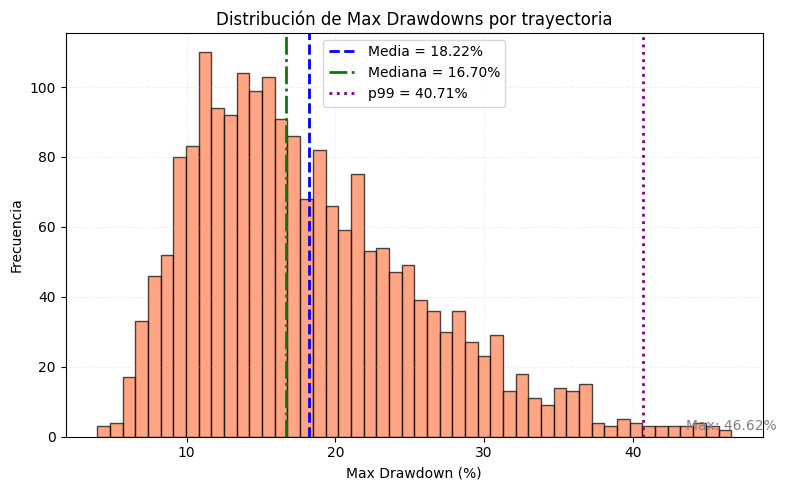

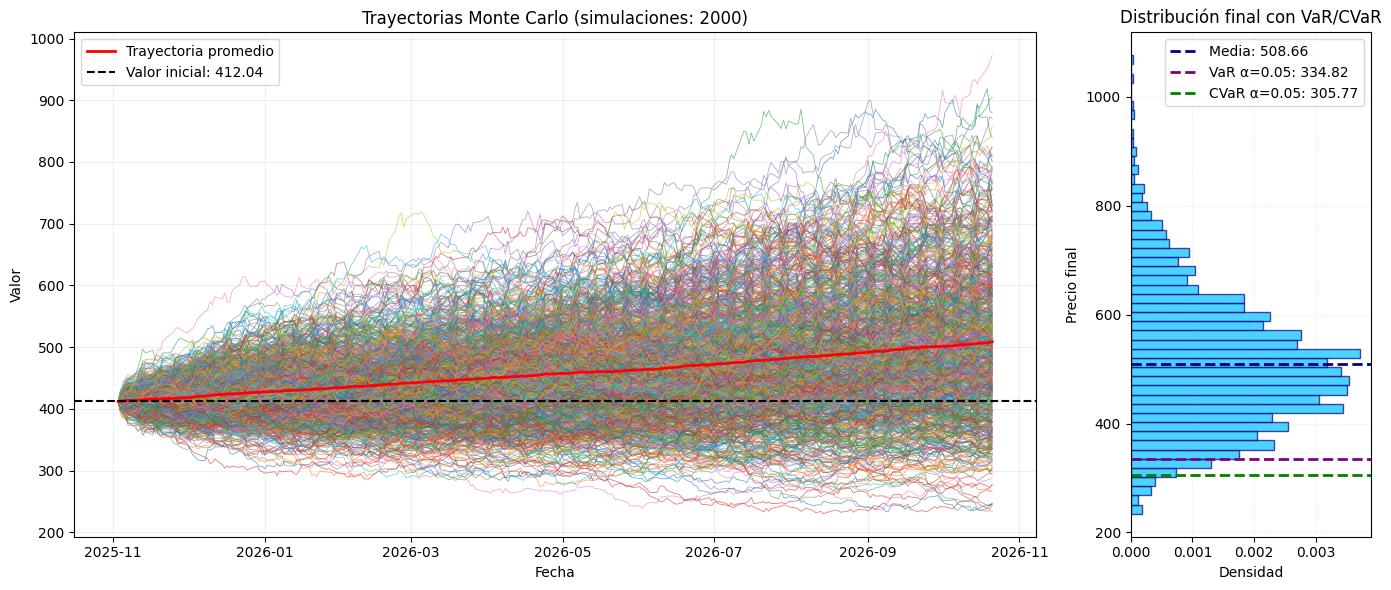

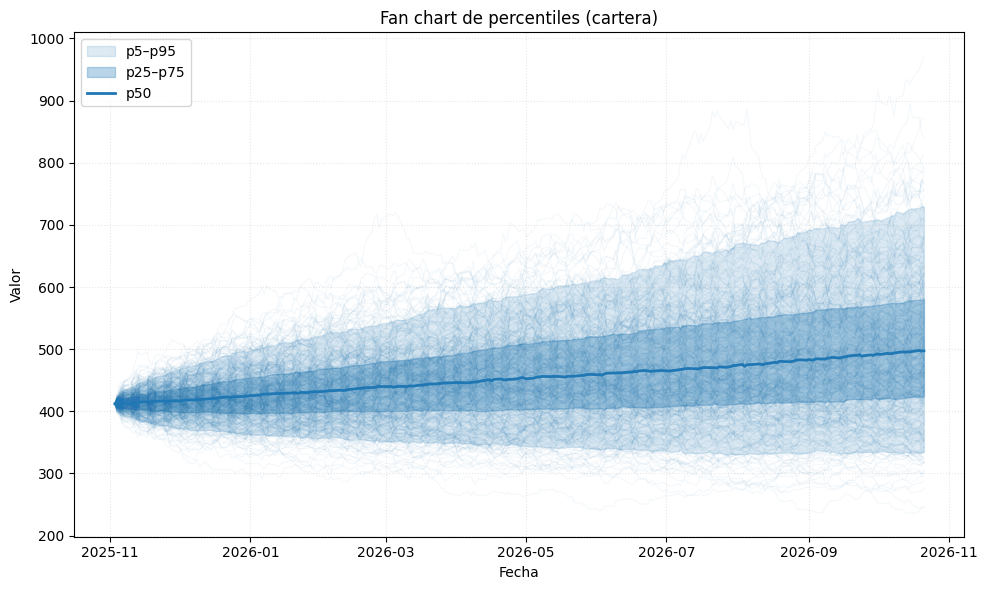

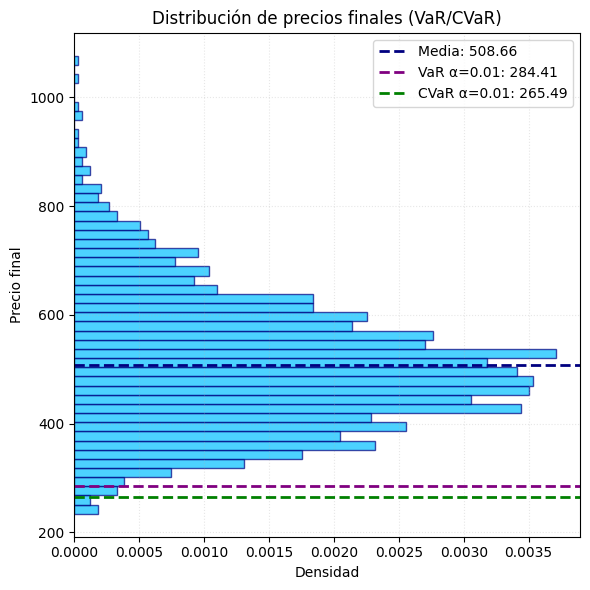

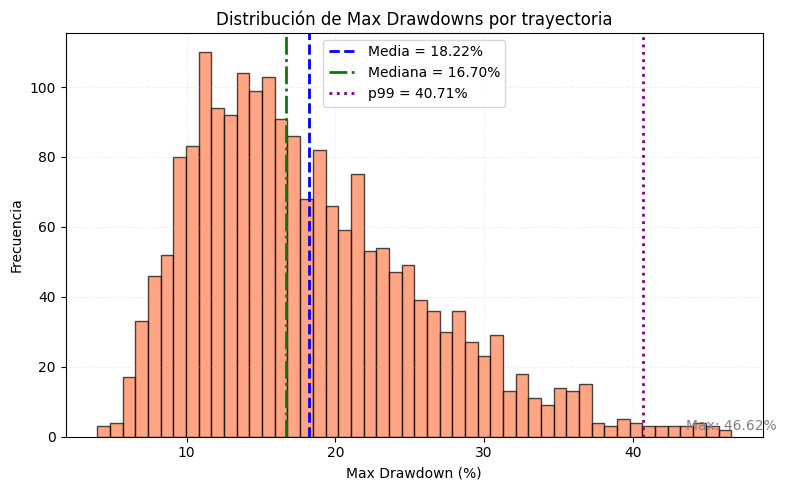

In [ ]:
from IPython.display import Markdown, display

from stock_toolkit.data.extractor import DataExtractor
from stock_toolkit.models.portfolio import Portfolio
from stock_toolkit.visualization import plots

# Monte Carlo puro: solo simulación y sus visualizaciones
extractor = DataExtractor.from_config()
series = extractor.fetch_many(["AAPL", "GOOGL", "SPY"], provider="yahoo", start_date="2020-01-01")
portfolio = Portfolio.from_equal_weights(series)

# Simulación de Monte Carlo
simulation = portfolio.run_monte_carlo(periods=252, simulations=2000, seed=123)

# Reporte SOLO con sección de Monte Carlo (sin métricas descriptivas)
report_md = portfolio.report(
    include_metrics=False,
    include_warnings=False,
    include_montecarlo=True,
    alpha=0.05,
    simulations=2000,
    periods=252,
    seed=123,
)
display(Markdown(report_md))

# 1) Trayectorias primero
plots.plot_portfolio_paths(simulation)

# 2) Panel (trayectorias + distribución final)
plots.plot_montecarlo_panel(simulation, alpha=0.05, max_paths=800, show_fit=False)

# 3) Fan chart de percentiles
plots.plot_fan_chart(simulation, quantiles=(5,25,50,75,95), max_paths=400)

# 4) Distribución de Max Drawdowns (una sola vez)
plots.plot_drawdown_distribution(simulation, percent=True)

